In [1]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fast_boolean_analysis import fourier_expand
from heisenberg_hamiltonians import HeisenbergJ1J2
from lattice_boolean_analysis import LBFFromEigenstateSeries
from mvmc_configs import MVMCConfig
from spin_lattices import (
    ChainLattice,
    KagomeLattice,
    SpinLattice,
    SquareLattice,
    TriangularLattice,
)
from misc_utils import get_abslargest_terms

from mvmc_multi_2023_03_24 import outdir, lattices, J2s


2023-03-27 13:34:33.062 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-03-27 13:34:33.066 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-03-27 13:34:33.121 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [3]:
name_to_lattice = {lattice.get_cache_id(): lattice for lattice in lattices}


In [55]:
dfs = []
for file in outdir.glob("*.feather"):
    lattice_name = (file.stem).split("_")[0]
    lattice = name_to_lattice[lattice_name]
    dfs.append(
        pd.read_feather(file).assign(lattice=lattice_name, overlap=lambda df: df["overlap"].abs())
    )
df = pd.concat(dfs, ignore_index=True).sort_values(["J2", "lattice"])


In [56]:
# for each J2, lattice, keep the best iteration
best_mvmc_iterations = (
    df.query("not iteration.isnull()").sort_values("energy").groupby(["J2", "lattice"]).head(1)
)


In [131]:
mvmc_evaluation = (
    df.query("type == 'mvmc'")[["J2", "lattice", "iteration", "energy", "overlap"]]
    .merge(
        df.query("type == 'ed'")[["J2", "lattice", "energy"]],
        on=["J2", "lattice"],
        suffixes=("_mvmc", "_ed"),
    )
    .assign(energy_lift=lambda df: -df["energy_mvmc"] / df["energy_ed"] + 1)
    .drop(["energy_mvmc", "energy_ed"], axis=1)
)

mvmc_evaluation = pd.concat(
    [
        mvmc_evaluation.assign(best=False),
        mvmc_evaluation.sort_values("energy_lift")
        .groupby(["J2", "lattice"])
        .head(1)
        .assign(best=True),
    ],
    ignore_index=True,
)


In [129]:
df_true_and_best = pd.concat(
    [df.query("iteration.isnull()"), best_mvmc_iterations], ignore_index=True
)


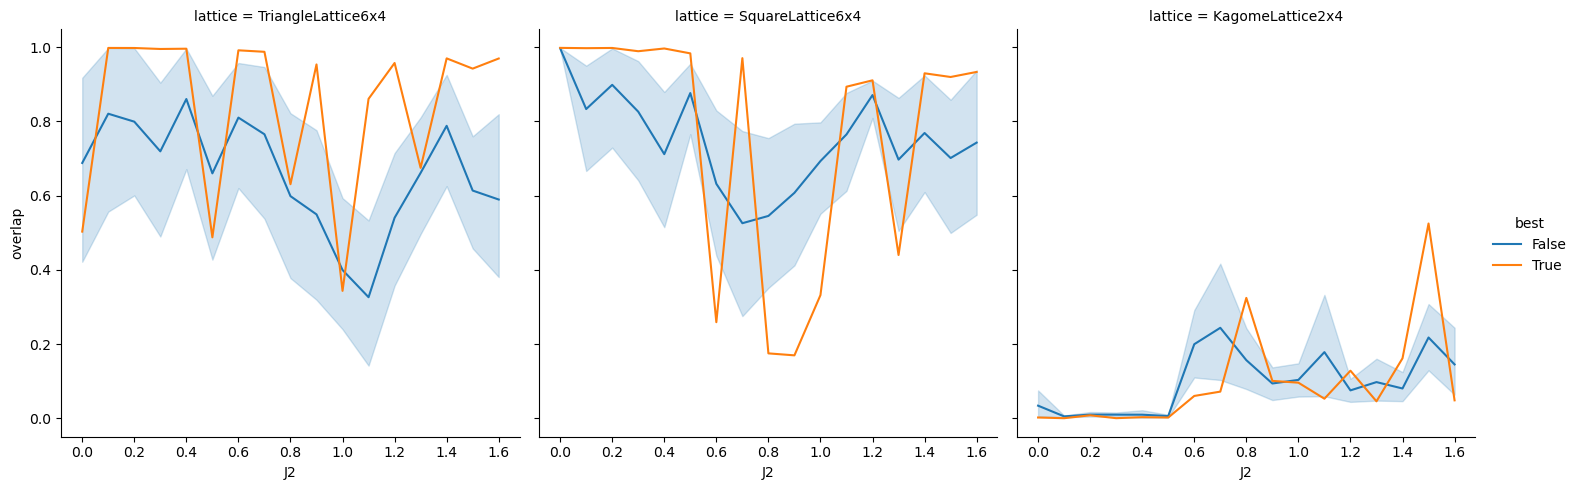

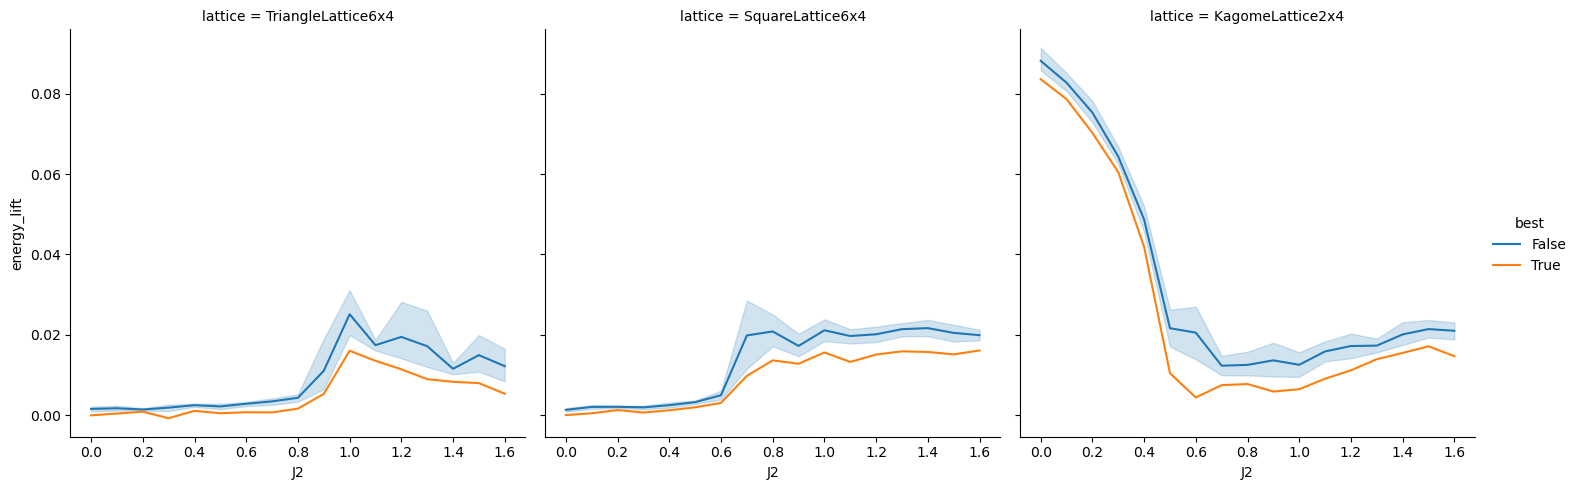

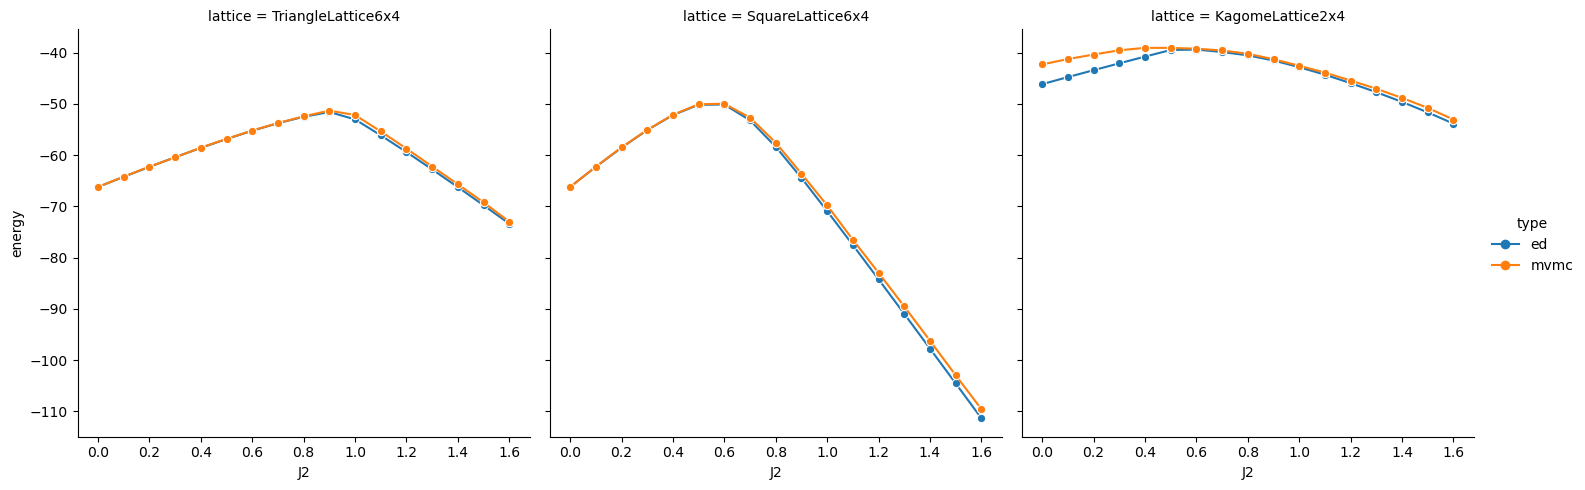

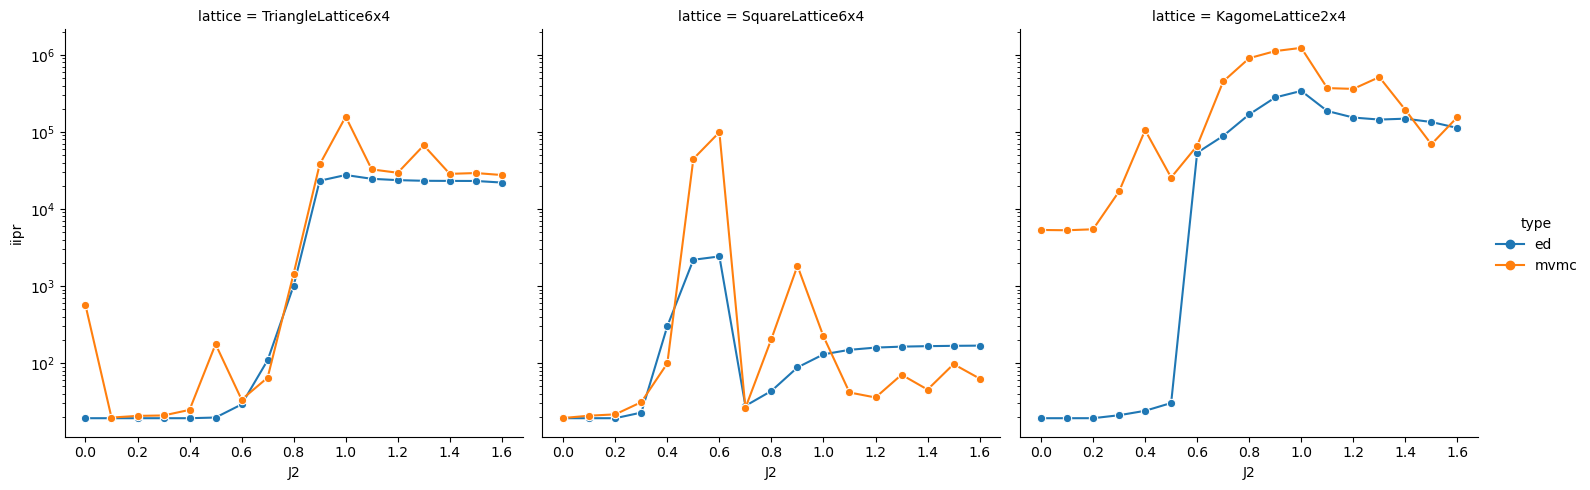

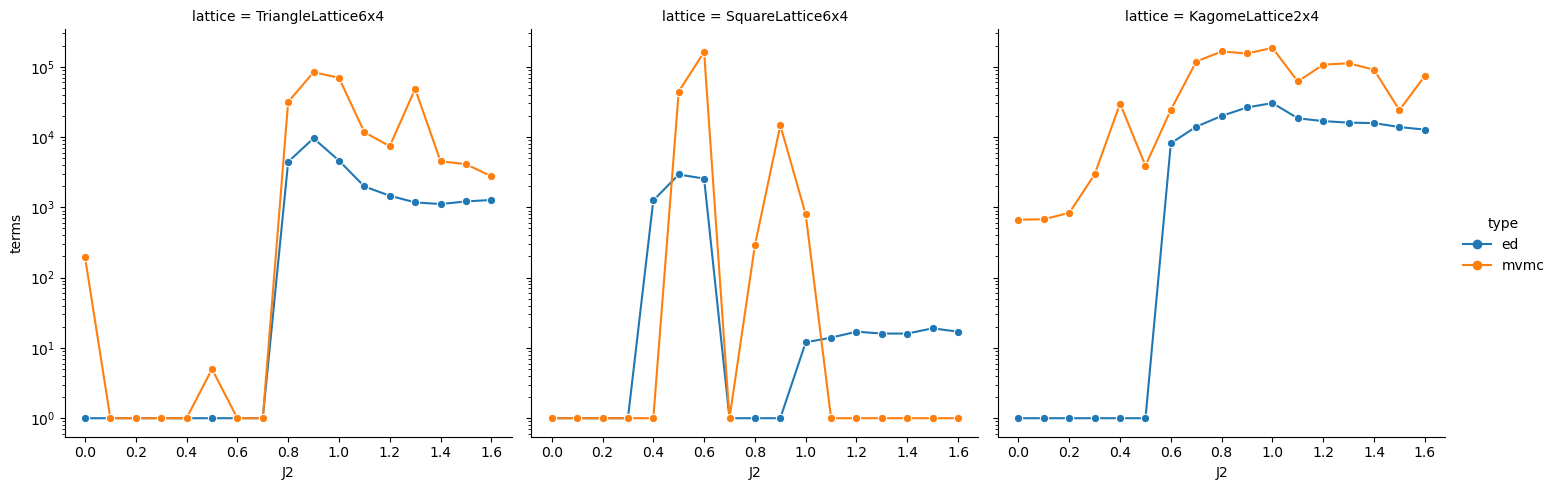

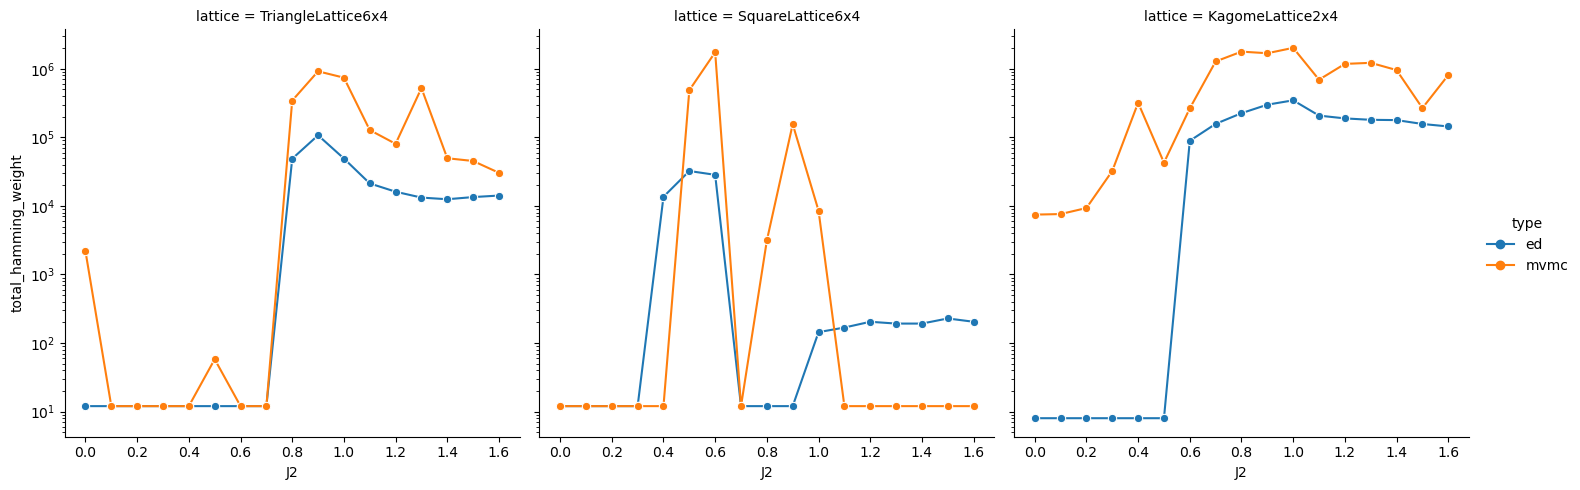

In [132]:
for y in ["overlap", "energy_lift"]:
    g = sns.relplot(
        mvmc_evaluation,
        x="J2",
        y=y,
        kind="line",
        col="lattice",
        dashes=False,
        markers=["o"],
        hue='best',
        col_order=sorted(mvmc_evaluation["lattice"].unique(), reverse=True),
    )

for y in ["energy", "iipr", "terms", "total_hamming_weight"]:
    g = sns.relplot(
        df_true_and_best,
        x="J2",
        y=y,
        kind="line",
        hue="type",
        col="lattice",
        dashes=False,
        style="type",
        markers=["o", "o"],
        col_order=sorted(df_true_and_best["lattice"].unique(), reverse=True),
    )
    if y in ["iipr", "terms", "total_hamming_weight"]:
        g.set(yscale="log")
